# Binary Classification Model. Train image model to recognise cat or dog

## Set Up Environment

In [1]:
!python --version
!pip --version

Python 3.12.13
pip 24.1.2 from /usr/local/lib/python3.12/dist-packages/pip (python 3.12)


In [2]:
%pip install -U fastai "fastcore<2.0"

## Preparing Dataset

In [3]:
from fastai.vision.all import *

set_seed(42, reproducible=True)

path = untar_data(URLs.PETS)
print(path)

/root/.fastai/data/oxford-iiit-pet


In [4]:
# for this dataset cat label start with uppercase and dog start with lowercase
def is_cat(label):
    return label[0].isupper()

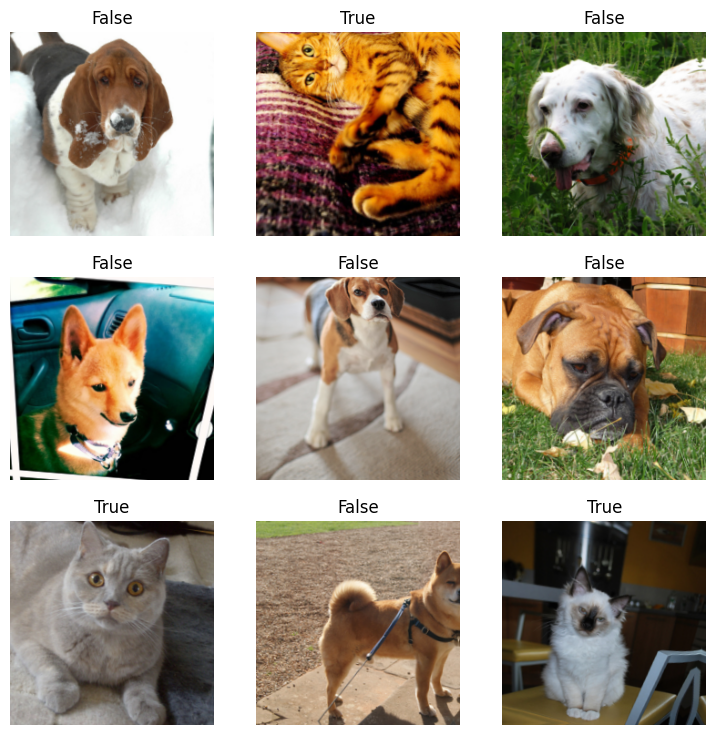

In [5]:
dls = ImageDataLoaders.from_name_func(
    path=path,
    fnames=get_image_files(path/"images"),
    label_func=is_cat,
    item_tfms=Resize(224),
    batch_tfms=aug_transforms(),
    valid_pct=0.2,
    seed=42
)

dls.show_batch(max_n=9)

In [6]:
print(f"n train: {len(dls.train_ds)}")
print(f"n validation: {len(dls.valid_ds)}")
print(f"n unique categories: {len(dls.vocab)}")

n train: 5912
n validation: 1478
n unique categories: 2


## Train Model

In [7]:
learn = vision_learner(dls, resnet34, metrics=error_rate)
learn.fine_tune(4)

epoch,train_loss,valid_loss,error_rate,time
0,0.170901,0.013357,0.004060,00:43


epoch,train_loss,valid_loss,error_rate,time
0,0.053870,0.271852,0.042625,00:45
1,0.043396,0.010373,0.004060,00:43
2,0.027319,0.005125,0.002030,00:45
3,0.012661,0.005935,0.002030,00:45


<Axes: title={'center': 'learning curve'}, xlabel='steps', ylabel='loss'>

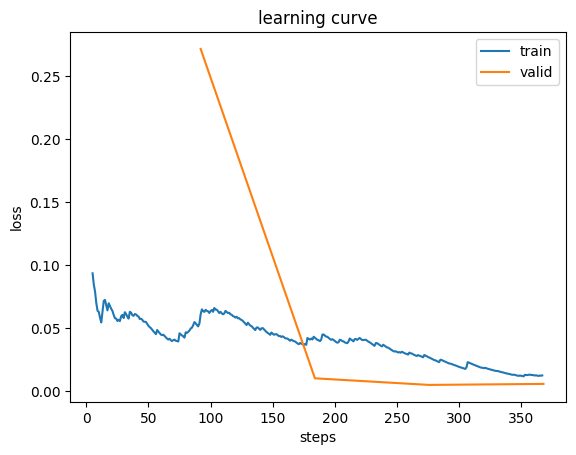

In [8]:
learn.recorder.plot_loss()

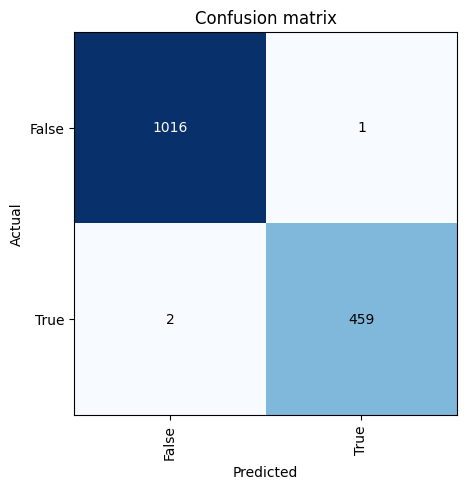

In [9]:
interp = ClassificationInterpretation.from_learner(learn)
interp.plot_confusion_matrix()

In [10]:
learn.export('/content/dog_cat_classifier.pkl')